### Measuring the area of overlap between two distributions

The overlap coefficient can be used as a measure of similarity between two distributions, and is defined as the area of overlap between two probability densities $f_1(x)$ and $f_2(x)$:
$$
OVL = \int \min[f_1(x),f_2(x)] dx
$$

In [20]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import norm
from scipy.integrate import trapezoid
from scipy.stats import gaussian_kde

Overlap coefficient = 0.617


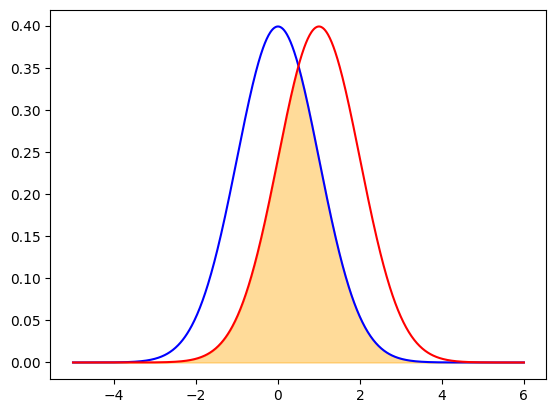

In [17]:
mu1, sigma1 = 0, 1
mu2, sigma2 = 1, 1

x = np.linspace(-5, 6, 1000)

pdf1 = norm.pdf(x, mu1, sigma1)
pdf2 = norm.pdf(x, mu2, sigma2)

plt.plot(x, pdf1, 'b')
plt.plot(x, pdf2, 'r')

plt.fill_between(
    x,
    np.minimum(pdf1, pdf2),
    color='orange',
    alpha=0.4
)

ovl = trapezoid(np.minimum(pdf1, pdf2), x)

print(f"Overlap coefficient = {ovl:.3f}")

Text(0, 0.5, 'Overlap coefficient')

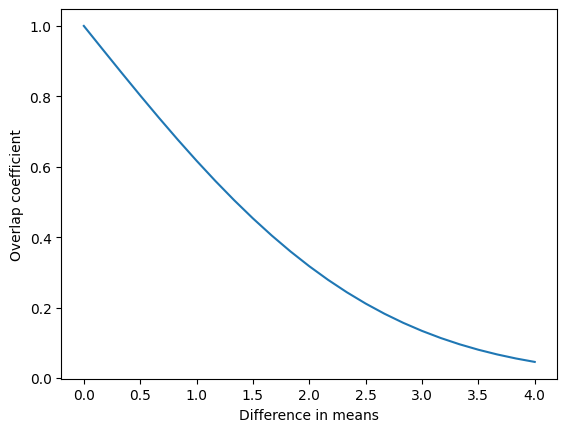

In [18]:
means = np.linspace(0, 4, 25)

ovls = []

for m in means:

    pdf2 = norm.pdf(x, m, 1)

    ovl = trapezoid(np.minimum(pdf1, pdf2), x)

    ovls.append(ovl)

plt.plot(means, ovls)

plt.xlabel("Difference in means")
plt.ylabel("Overlap coefficient")

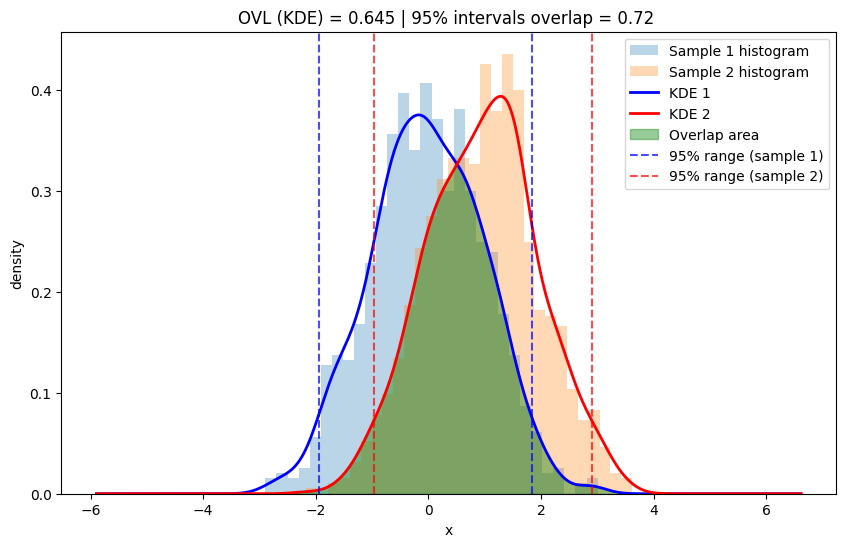

In [45]:
# --- parameters (example) ---
mu1, sigma1 = 0, 1
mu2, sigma2 = 1, 1

# --- samples ---
sample1 = np.random.normal(mu1, sigma1, 1000)
sample2 = np.random.normal(mu2, sigma2, 1000)

# --- 95% central intervals ---
l1, u1 = np.percentile(sample1, [2.5, 97.5])
l2, u2 = np.percentile(sample2, [2.5, 97.5])

# --- KDEs ---
kde1 = gaussian_kde(sample1)
kde2 = gaussian_kde(sample2)

# --- common x-grid (important!) ---
xmin = min(sample1.min(), sample2.min()) - 3
xmax = max(sample1.max(), sample2.max()) + 3
x = np.linspace(xmin, xmax, 1000)

y1 = kde1(x)
y2 = kde2(x)

# --- overlap density ---
overlap = np.minimum(y1, y2)

# --- 95% central ranges overlap ---
interval_overlap = min(u1, u2) - max(l1, l2)

interval_width = max(u1 - l1, u2 - l2)
normalized_overlap = interval_overlap / interval_width

# --- overlap coefficient (area) ---
ovl_sample = trapezoid(overlap, x)

# --- plot ---
plt.figure(figsize=(10, 6))

# Histograms (density=True makes them comparable to KDE)
plt.hist(sample1, bins=30, density=True, alpha=0.3, label="Sample 1 histogram")
plt.hist(sample2, bins=30, density=True, alpha=0.3, label="Sample 2 histogram")

# KDE curves
plt.plot(x, y1, 'b', linewidth=2, label="KDE 1")
plt.plot(x, y2, 'r', linewidth=2, label="KDE 2")

# overlap shading
plt.fill_between(x, overlap, color='green', alpha=0.4, label="Overlap area")

# --- 95% interval lines ---
plt.axvline(l1, color='blue', linestyle='--', alpha=0.7)
plt.axvline(u1, color='blue', linestyle='--', alpha=0.7, label="95% range (sample 1)")

plt.axvline(l2, color='red', linestyle='--', alpha=0.7)
plt.axvline(u2, color='red', linestyle='--', alpha=0.7, label="95% range (sample 2)")

plt.title(
    f"OVL (KDE) = {ovl_sample:.3f} | "
    f"95% intervals overlap = {normalized_overlap:.2f} "
)
plt.xlabel("x")
plt.ylabel("density")
plt.legend()
plt.show()